The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


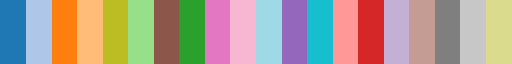

In [3]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
offline_cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

util.my_cmap

# 1. Before BDT

In [ ]:
# Load data files wrong charge e
MC_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run1_deimos_1.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

for df in [MC_4S_wc_e,data_4S_wc_e,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)

In [6]:
mc_4S_wc_noBDT = util.apply_mva_bcs(MC_4S_wc_e, training_variables, cut='ell_p>0', library=None,model='multiclass')
data_4S_wc_noBDT = util.apply_mva_bcs(data_4S_wc_e, training_variables, cut='ell_p>0', library=None,model='multiclass')

MC_4S_wc_noBDT=util.apply_pid_corrections(df=mc_4S_wc_noBDT, run='run1', channel='e', corr_col_name='total_PIDweight')

Is best selected True
Is best selected True
Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_p', 'ell_BFbrems_charge', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_p', 'K_charge', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_p', 'pi1_charge', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_p', 'pi2_charge', 'pi2_PDG', 'pi2_mcPDG']


In [7]:
samples_wc_noBDT=util.classify_mc_dict(MC_4S_wc_noBDT, 'e', template=False)
mpl_wc_noBDT=util.mpl(samples_wc_noBDT,data_4S_wc_noBDT)
for name, df in samples_wc_noBDT.items():
    print(name, len(df))

bkg_fakeD 6117469
bkg_fakeL 27322
bkg_fakeTracks 105674
bkg_continuum 48594
bkg_combinatorial 853656
bkg_hadronicB_secondaryL 21774
bkg_other_TDTl 0
$D\tau\nu$ 1
$D^\ast\tau\nu$ 0
$D\ell\nu$ 0
$D^\ast\ell\nu$ 0
$D^{\ast\ast}\tau\nu$ 0
$D^{\ast\ast}\ell\nu$_narrow 0
$D^{\ast\ast}\ell\nu$_broad 0
$D\ell\nu$_gap 0
bkg_other_signal 0


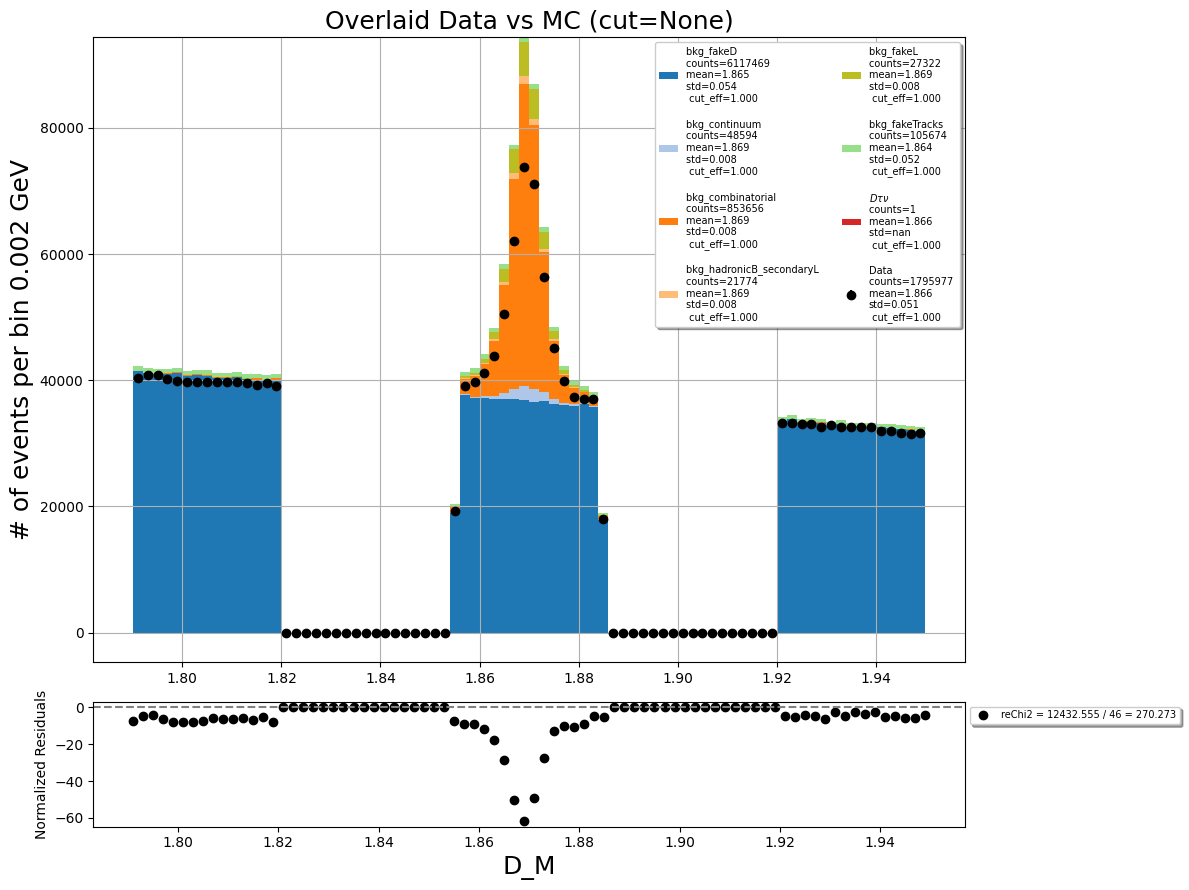

In [8]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc_noBDT.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=None,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

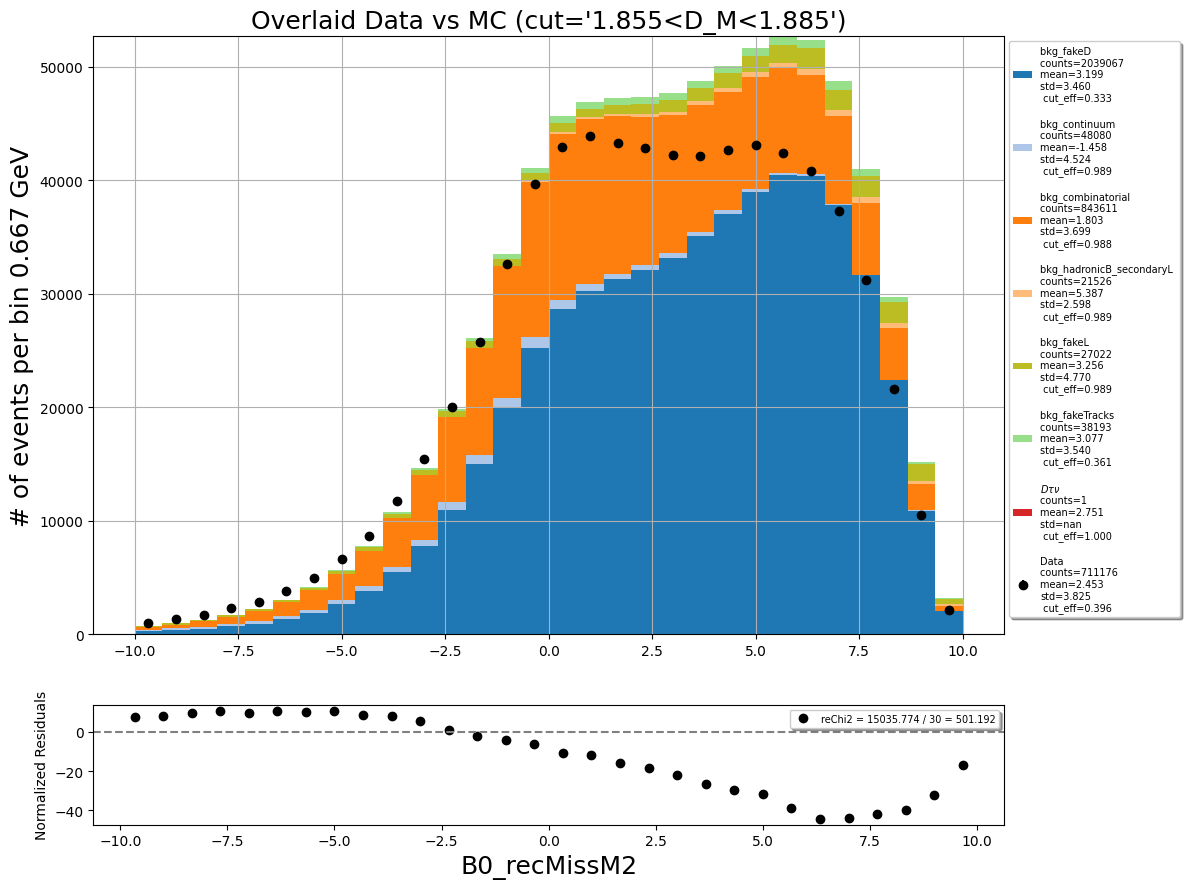

In [22]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25,}
data_hist_all, mc_hist_all = mpl_wc_noBDT.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PIDweight'

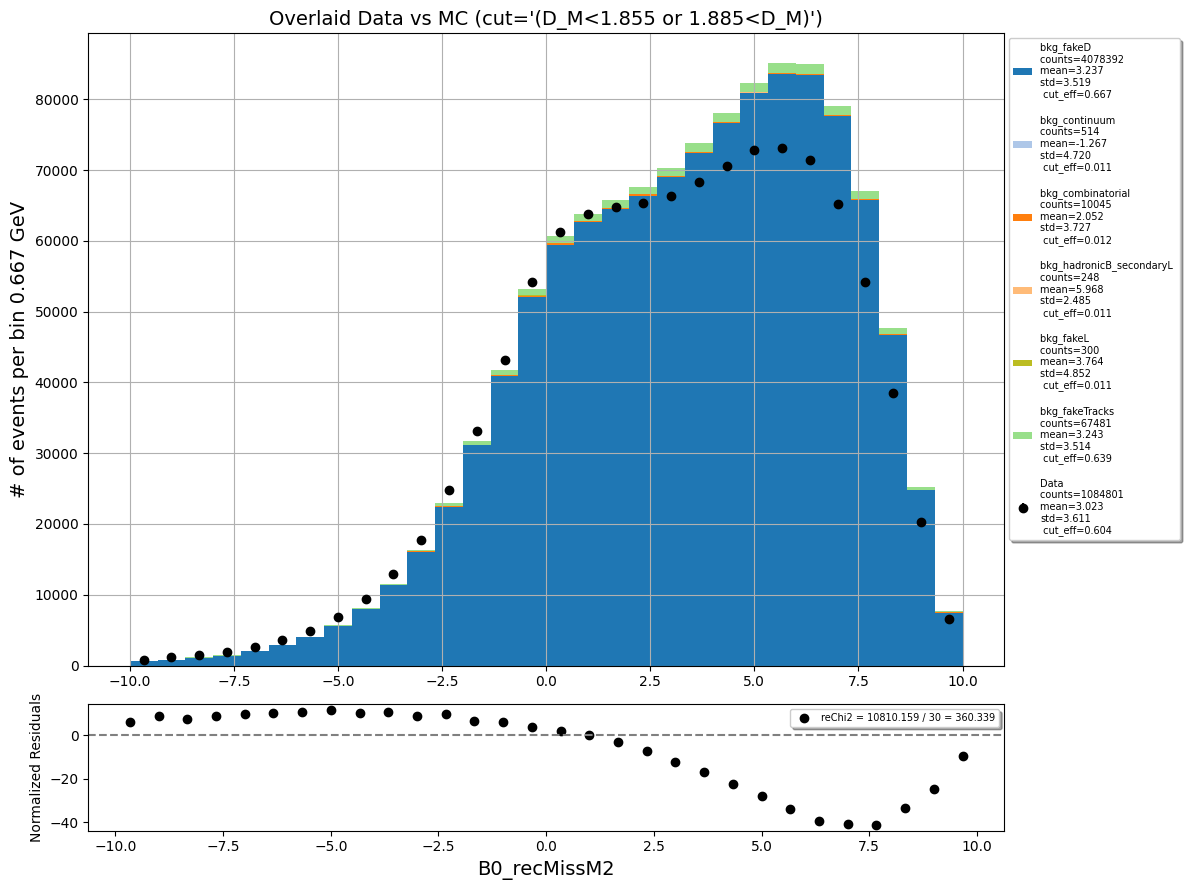

In [23]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_wc_noBDT.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M)',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

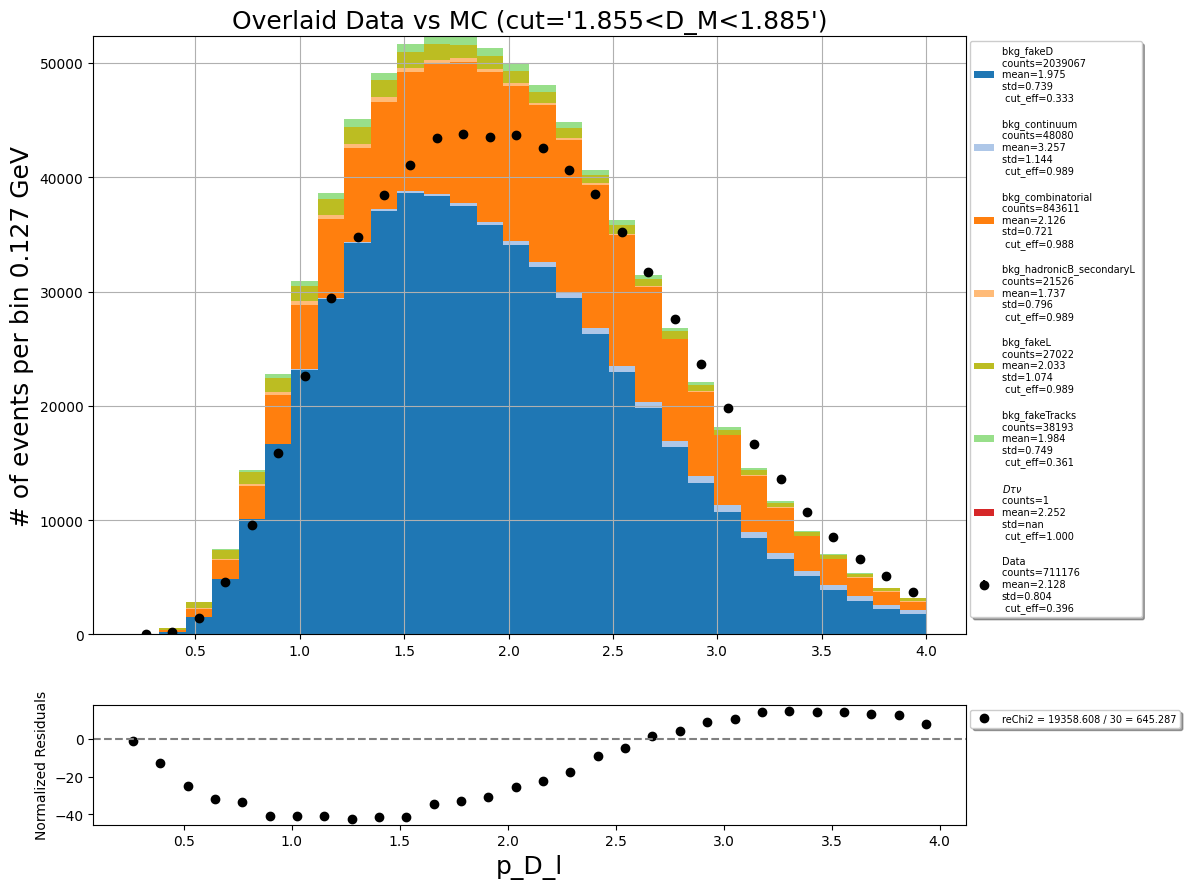

In [24]:
b1 = np.linspace(0.2,4,31)
weights={'all_mc':0.25,}
data_hist_all, mc_hist_all = mpl_wc_noBDT.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PIDweight

# 2. BDT signal region

In [12]:
# Load data files
MC_4S_wc = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:MC_wc_e_loose'],
                          library="pd",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:Data_wc_e_loose'],
                          library="pd",
                          cut = cut,
                          filter_branch=lambda branch: branch.name in columns)

MC_4S_wc_loose = util.apply_pid_corrections(df=MC_4S_wc, run='run1', channel='e', corr_col_name='total_PIDweight')

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_p', 'ell_BFbrems_charge', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_p', 'K_charge', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_p', 'pi1_charge', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_p', 'pi2_charge', 'pi2_PDG', 'pi2_mcPDG']


In [13]:
samples_wc=util.classify_mc_dict(MC_4S_wc_loose, 'e', template=False)
mpl_wc=util.mpl(samples_wc,data_4S_wc)
for name, df in samples_wc.items():
    print(name, len(df))

bkg_fakeD 269778
bkg_fakeL 3485
bkg_fakeTracks 6097
bkg_continuum 4416
bkg_combinatorial 155847
bkg_hadronicB_secondaryL 3395
bkg_other_TDTl 0
$D\tau\nu$ 0
$D^\ast\tau\nu$ 0
$D\ell\nu$ 0
$D^\ast\ell\nu$ 0
$D^{\ast\ast}\tau\nu$ 0
$D^{\ast\ast}\ell\nu$_narrow 0
$D^{\ast\ast}\ell\nu$_broad 0
$D\ell\nu$_gap 0
bkg_other_signal 0


cut= sig_prob>0.2 and fakeD_prob<0.15 and continuum_prob<0.5 and combinatorial_prob<0.6


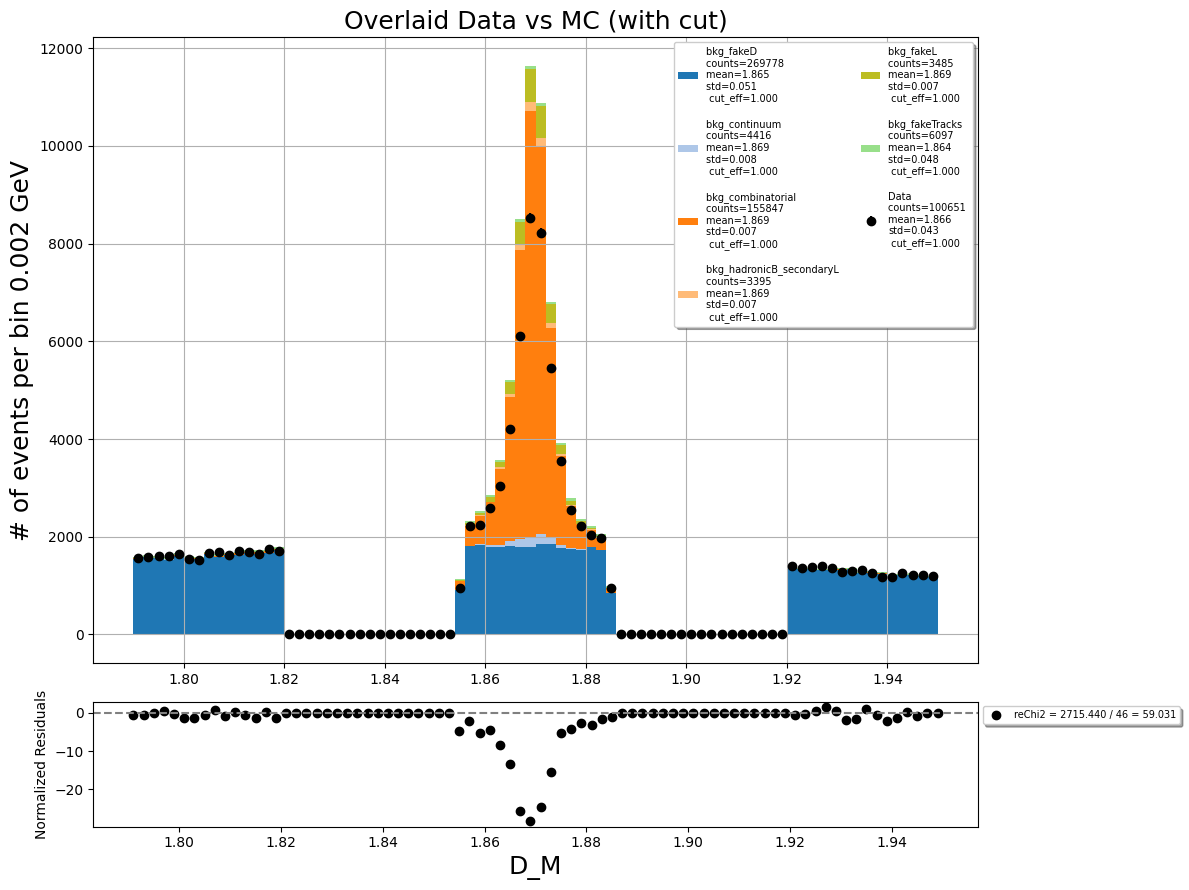

In [15]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=lgb_loose,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

cut= sig_prob>0.2 and fakeD_prob<0.15 and continuum_prob<0.5 and combinatorial_prob<0.6 and 1.855<D_M<1.885


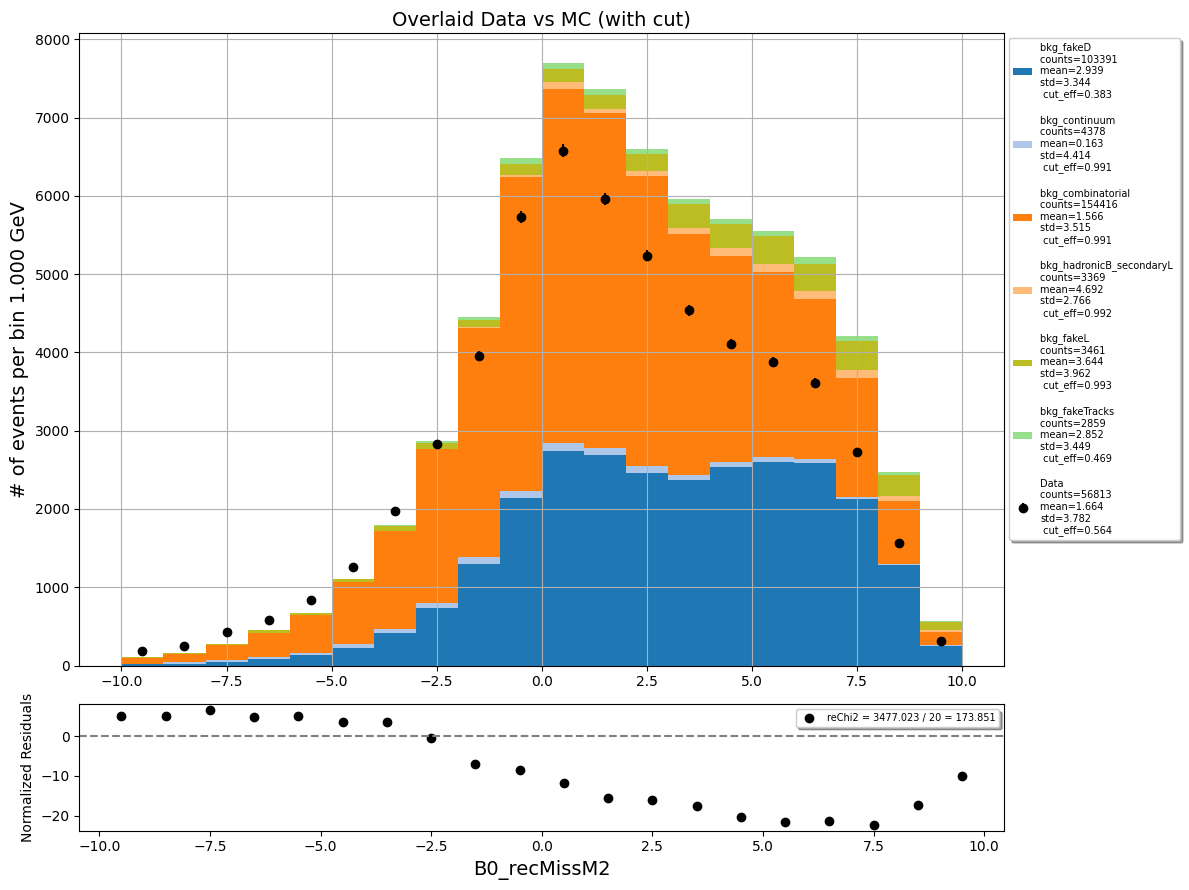

In [25]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=lgb_loose + ' and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

cut= sig_prob>0.2 and fakeD_prob<0.15 and continuum_prob<0.5 and combinatorial_prob<0.6 and (D_M<1.855 or 1.885<D_M)


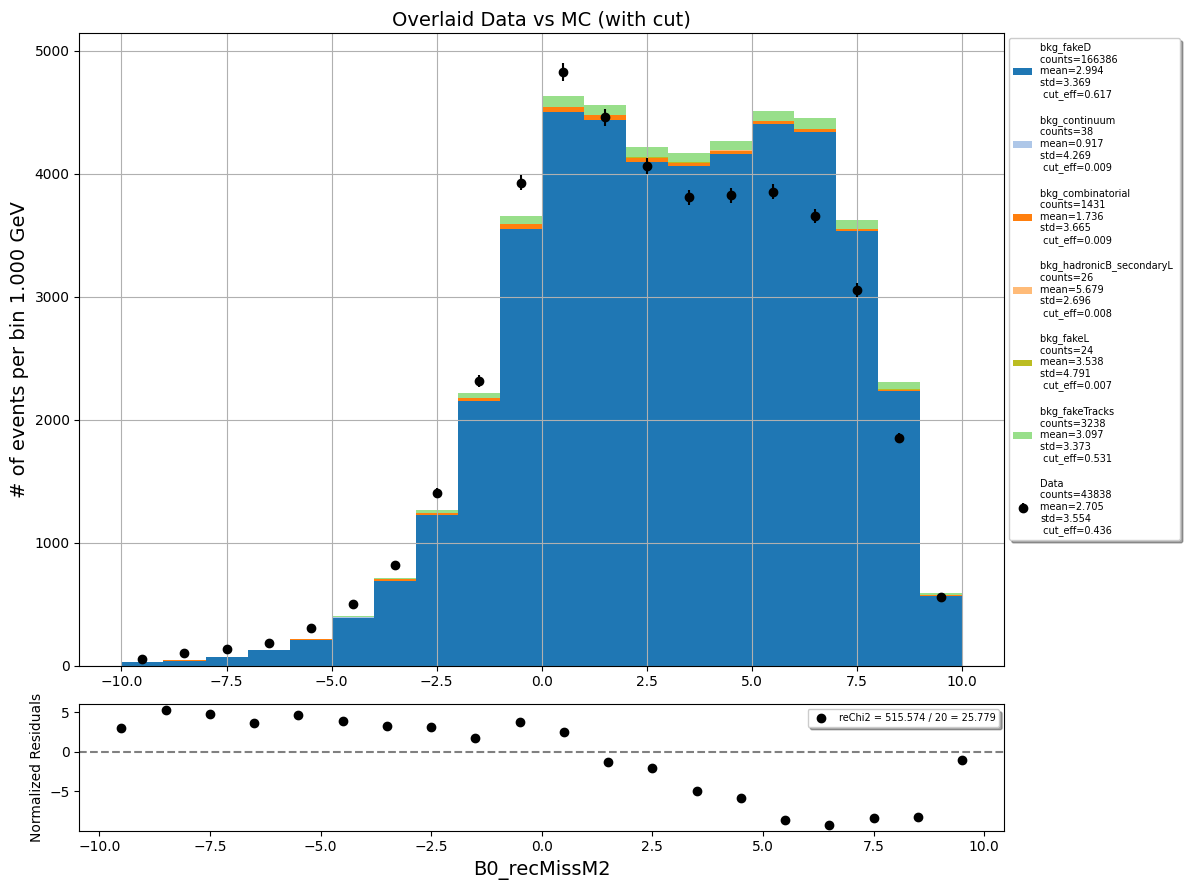

In [26]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=lgb_loose + ' and (D_M<1.855 or 1.885<D_M)',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= sig_prob>0.2 and fakeD_prob<0.15 and continuum_prob<0.5 and combinatorial_prob<0.6 and 1.855<D_M<1.885


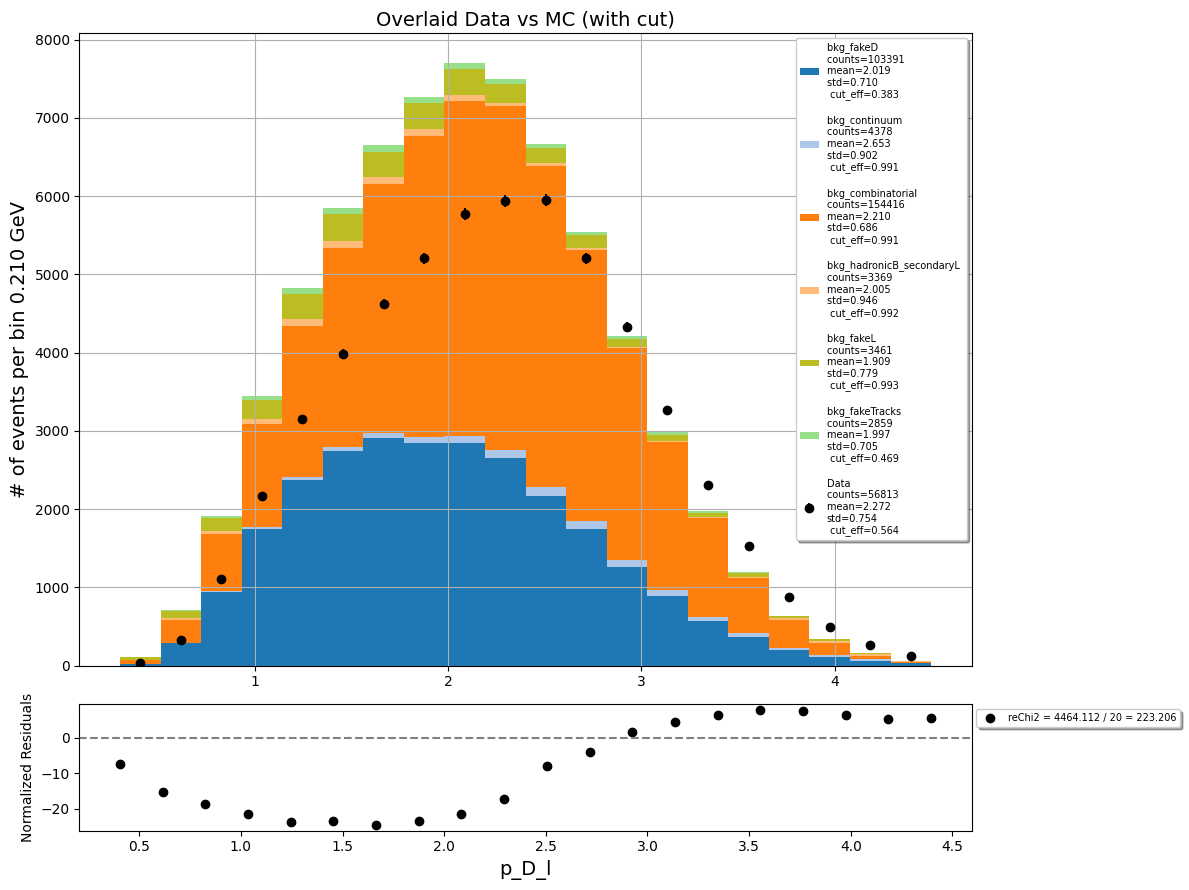

In [27]:
b1 = np.linspace(0.3,4.5,21)
weights={'all_mc':0.25,}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=lgb_loose + ' and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=1,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'


[bkg_combinatorial] N=155847  sum(BB_weight)=151488.395
D_category
BBbar_unmeasured:5+-body    46444.000000
BBbar_unmeasured:4-body     31107.000000
BBbar_semileptonic          25888.000000
BBbar_measured_hadronic     24004.225554
BBbar_unmeasured:3-body     21503.000000
BBbar_unmeasured:2-body      3912.000000
Name: D_side_weight, dtype: float64


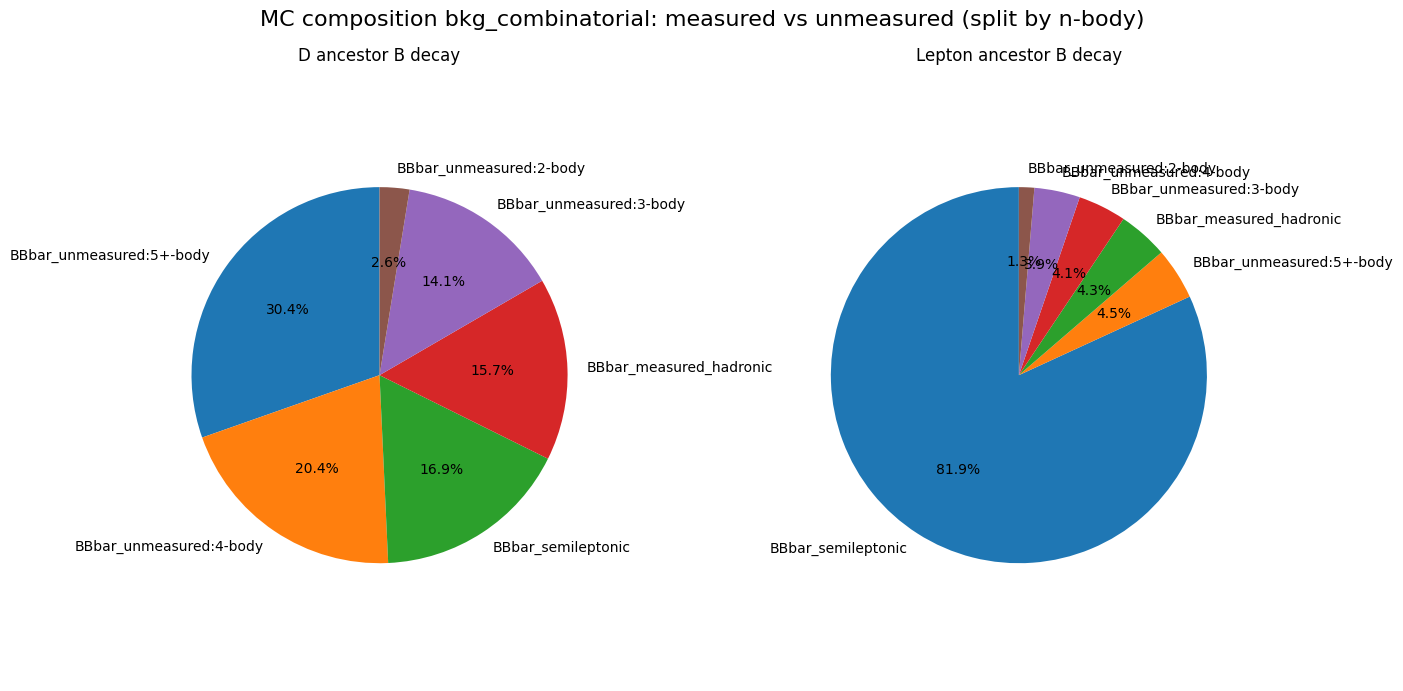


[bkg_hadronicB_secondaryL] N=3395  sum(BB_weight)=3303.442
D_category
BBbar_measured_hadronic     983.442248
BBbar_unmeasured:4-body     713.000000
BBbar_unmeasured:5+-body    669.000000
BBbar_semileptonic          423.000000
BBbar_unmeasured:3-body     390.000000
BBbar_unmeasured:2-body     125.000000
Name: D_side_weight, dtype: float64


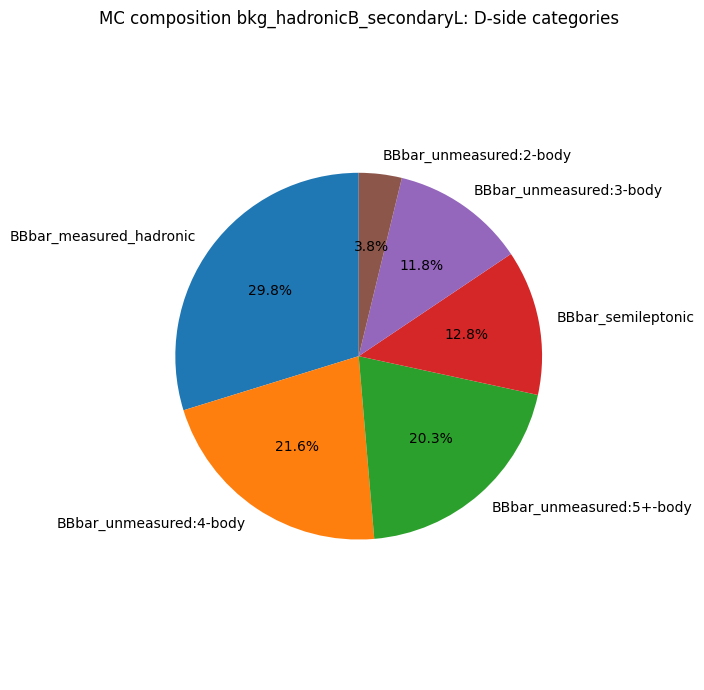

In [21]:
weights={'BBbar_measured_hadronic':1,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':1,
         'BBbar_unmeasured:3-body':1,
         'BBbar_unmeasured:4-body':1,
         'BBbar_unmeasured:5+-body':1,}

samples_wc_sub = util.reweight_BBbar_background(samples_wc, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = True, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = None, ell_replacement_map = None)
for name, df in samples_wc_sub.items():
    df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
mpl_wc_sub=util.mpl(samples_wc_sub,data_4S_wc)

cut= 1.855<D_M<1.885 and fakeD_prob<0.1


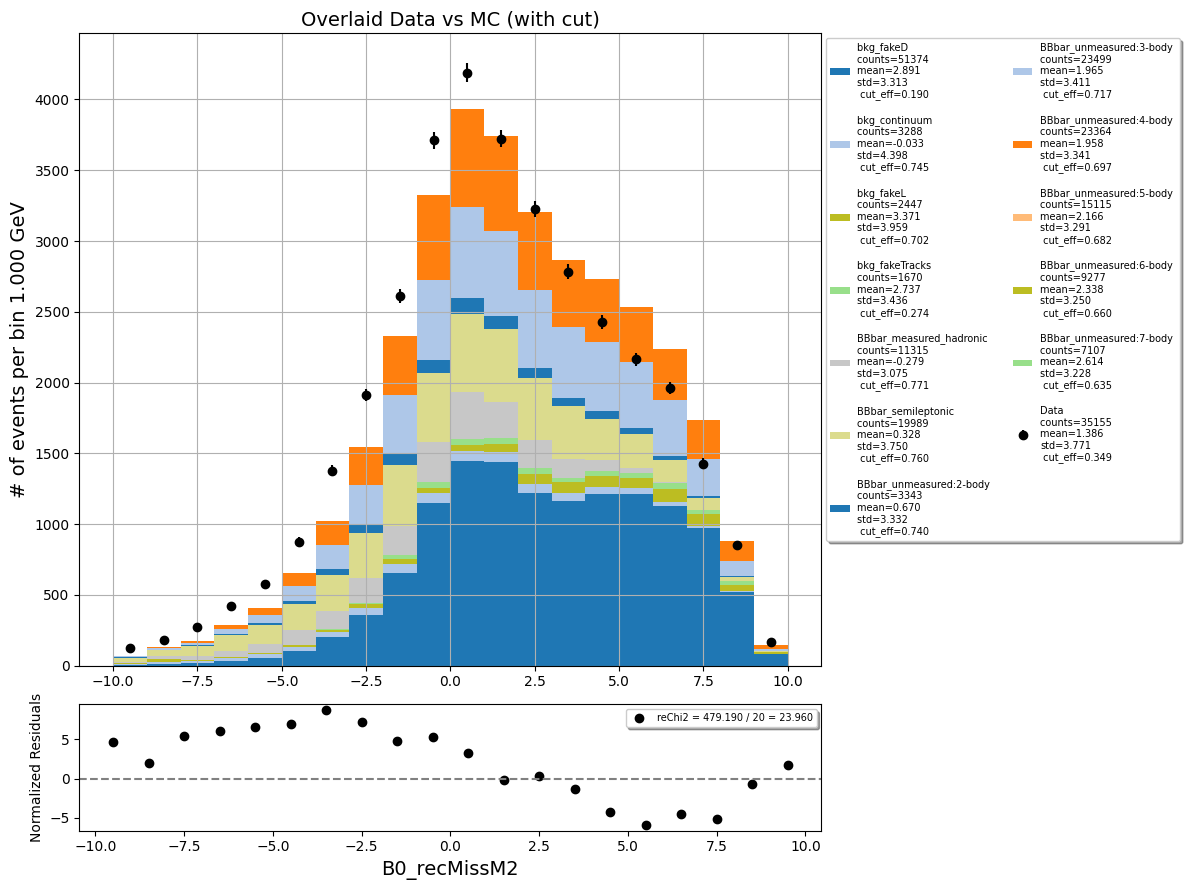

In [7]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,
         'bkg_fakeD':0.25 * 0.97,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5-body':0,
         'BBbar_unmeasured:6-body':0,
         'BBbar_unmeasured:7-body':0,}
data_hist_all, mc_hist_all = mpl_wc_sub.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


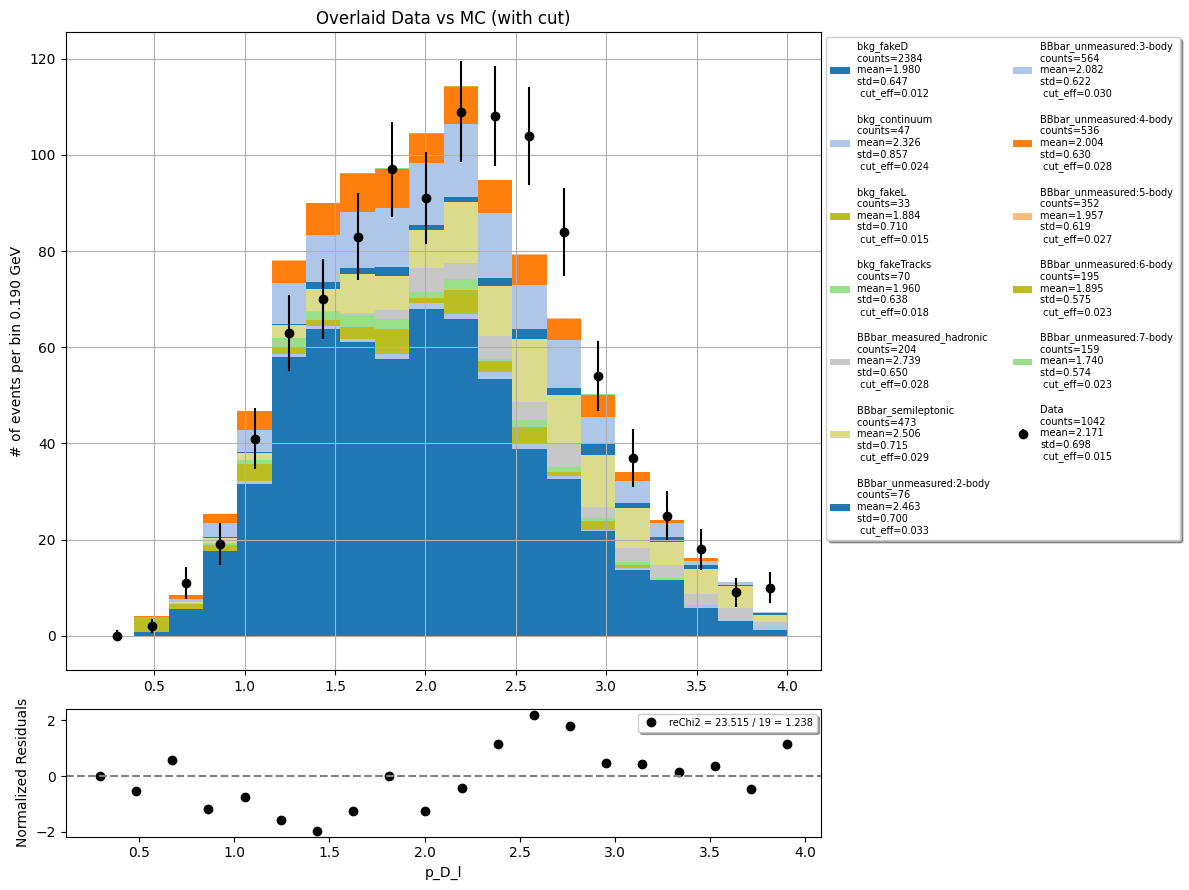

In [18]:
b1 = np.linspace(0.2,4,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


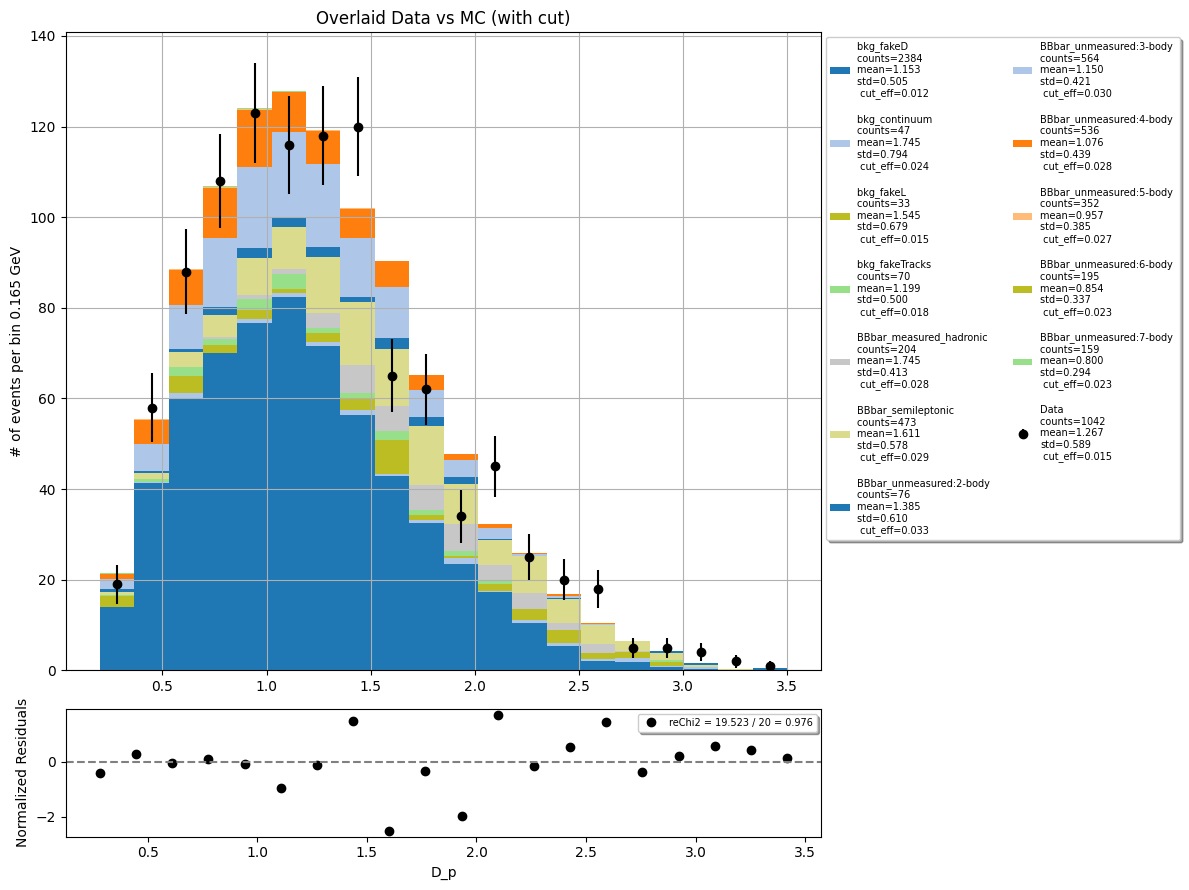

In [19]:
b1 = np.linspace(0.2,3.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='D_p',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18


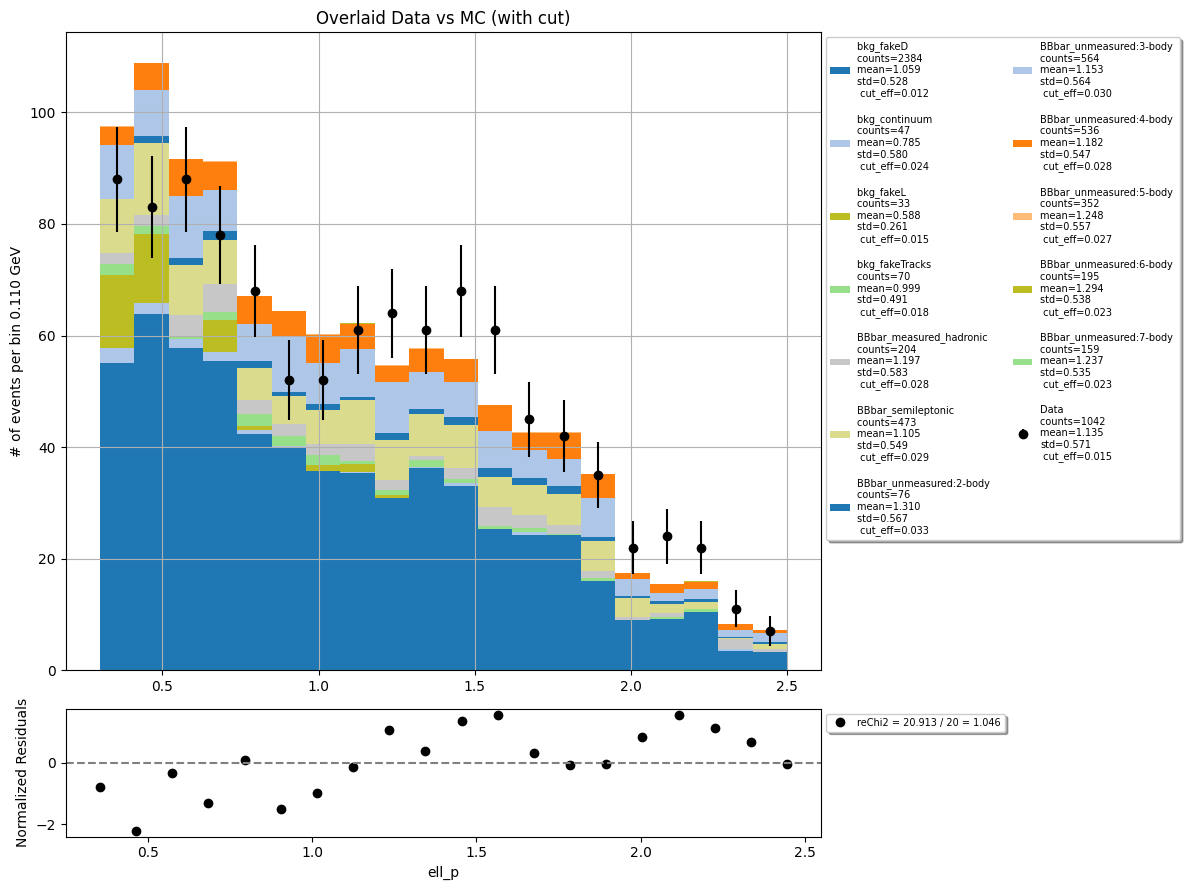

In [20]:
b1 = np.linspace(0.3,2.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_wc.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut='1.855<D_M<1.885 and B0_vtxReChi2>3 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

# 3. Fit combinatorial components

In [41]:
MM2_bins = np.linspace(-10,10,41)
p_D_l_bins = np.linspace(0.3,4.3,41)
MM2_bins_sb = np.linspace(-10,10,21)
p_D_l_bins_sb = np.linspace(0.3,4.3,21)
    
temp_data_sr,temp_data_sb,temp_data_sr_merged, temp_data_sb_merged = util.create_templates_new(
    samples=samples_wc_sub,cut='fakeD_prob<0.1',variables=['B0_recMissM2','p_D_l'],
    bins_sr=[MM2_bins, p_D_l_bins],bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
     scale_lumi=1, bin_threshold=10,merge_threshold=5,
    use_real_data_instead_of_asimov=True, real_data=df_data_4S_wc,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight',
    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal', 'others',
                      r'$D\ell\nu$_gap',
                       # 'bkg_fakeD', 
                       # 'bkg_continuum',
#                       r'$D^{\ast\ast}\ell\nu$_broad',
#                       r'$D^{\ast\ast}\ell\nu$_narrow',
#                       r'$D\ell\nu$',
#                       r'$D^\ast\ell\nu$',
#                       r'$D\tau\nu$', 
#                       r'$D^\ast\tau\nu$', 
#                       r'$D^{\ast\ast}\tau\nu$',
                      #  'bkg_fakeTracks',
                      # 'bkg_TDFl','bkg_singleBbkg',
                      # 'bkg_combinatorial',
                      ],
    sample_weights={#r'$D\ell\nu$_gap_pi':           0, # 2618 events 
                    r'$D\ell\nu$_gap':          0, # 2404
                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435, # 11540 events from 1/ab
                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25,
                    r'$D\ell\nu$':                  0.25,
                    r'$D^\ast\ell\nu$':             0.25,
                    r'$D\tau\nu$':                  0.25 , 
                    r'$D^\ast\tau\nu$':             0.25 , 
                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33,
                    'bkg_fakeD':                    0.25, # here for signal region
                    'bkg_fakeL':                    0.25,
                    'bkg_continuum':                0.25,
                    'bkg_combinatorial':            0.25,
                    'bkg_hadronicB_secondaryL':     0.25,
                    'bkg_fakeTracks':               0.25,
                    'BBbar_measured_hadronic':      0.25,
                    'BBbar_semileptonic':           0.25,
                    'BBbar_unmeasured:2-body':      0.25,
                    'BBbar_unmeasured:3-body':      0.25,
                    'BBbar_unmeasured:4-body':      0.25,
                    'BBbar_unmeasured:5-body':      0.25,
                    'BBbar_unmeasured:6-body':      0.25,
                    'BBbar_unmeasured:7-body':      0.25,
                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 425, new template (merge small bins) length = 425
creating new templates with merged bins in the D mass sidebands, original template length = 119, new template (merge small bins) length = 119


In [42]:
import json
spec_wc_e = util.create_workspace(temp_data_channels=[temp_data_sr,temp_data_sb],mc_uncer=True,fakeD_uncer=True)
spec_wc_e['measurements'][0]['config']['poi']="BBbar_measured_hadronic_norm"
print(json.dumps(spec_wc_e, sort_keys=True, indent=4))

{
    "channels": [
        {
            "name": "channel_0",
            "samples": [
                {
                    "data": [
                        0.59,
                        1.4,
                        0.9,
                        0.73,
                        1.67,
                        0.97,
                        1.18,
                        1.24,
                        1.69,
                        2.11,
                        2.22,
                        1.26,
                        1.33,
                        3.03,
                        1.89,
                        4.25,
                        1.78,
                        1.45,
                        1.15,
                        0.94,
                        0.93,
                        1.7,
                        3.91,
                        4.33,
                        3.05,
                        3.53,
                        1.88,
                        0.69,
                        0.6

In [43]:
import cabinetry, pyhf
cabinetry.set_logging()

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier BBbar_measured_hadronic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_semileptonic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:2-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:3-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:4-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:5-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:6-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:7-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance

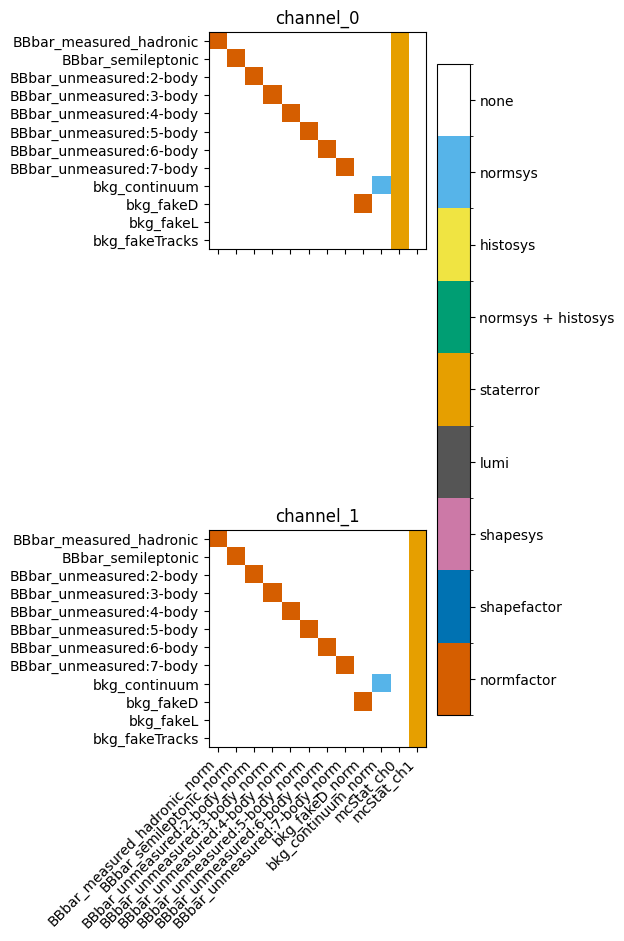

In [44]:
model_wc_e, data_wc_e = cabinetry.model_utils.model_and_data(spec_wc_e)
pars = model_wc_e.config.suggested_init()

norm_parameter_names = [par for par in model_wc_e.config.par_order if par.endswith('_norm')]
for par in norm_parameter_names:
    model_wc_e.config.param_set(par).suggested_bounds=[[0,1]]
    # if par=='SemileptonicB2D_PrimaryLepton_norm':
    #     model_comb.config.param_set(par).suggested_bounds=[[-0.9,1.1]]
    if par.startswith('$'):
        model_wc_e.config.param_set(par).suggested_fixed=[True]

model_wc_e.config.param_set('bkg_fakeD_norm').suggested_fixed=[False]
model_wc_e.config.param_set('bkg_continuum_norm').suggested_fixed=[True]
model_wc_e.config.param_set('BBbar_semileptonic_norm').suggested_fixed=[True]
model_wc_e.config.param_set('BBbar_measured_hadronic_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_init=[1]
model_wc_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_init=[1]
model_wc_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_fixed=[False]
model_wc_e.config.param_set('BBbar_unmeasured:4-body_norm').suggested_init=[0.68]
model_wc_e.config.param_set('BBbar_unmeasured:5-body_norm').suggested_init=[0.1]
model_wc_e.config.param_set('BBbar_unmeasured:6-body_norm').suggested_init=[0.1]
model_wc_e.config.param_set('BBbar_unmeasured:7-body_norm').suggested_init=[0.1]

cabinetry.visualize.modifier_grid(model_wc_e)
# cabinetry.visualize.modifier_grid(pyhf.Workspace(spec_comb_e).model())

In [45]:
%%time
# e mode, staterror
fit_results = cabinetry.fit.fit(model=model_wc_e, data=data_wc_e,goodness_of_fit=True,
#                                 init_pars=[1]*7+[10]*3+pars[10:],
                                # fix_pars=[True]*4
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2591                       │            Nfcn = 325571             │
│ EDM = 8.81e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

CPU times: user 2min 16s, sys: 196 ms, total: 2min 16s
Wall time: 2min 16s


# Check WC vs. CC

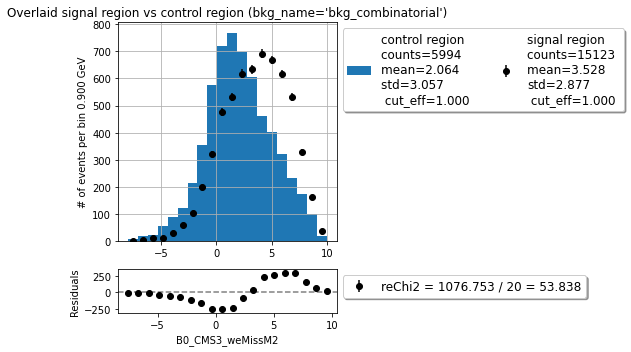

In [9]:
# compare control vs signal regions MC
b1 = np.linspace(-8,10,21)
weights = {'control region': 1,
         'signal region': 6/15}
mpl.plot_mc_sig_control(variable='B0_CMS3_weMissM2',bins=b1,
                        bkg_name='bkg_combinatorial',
                        cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

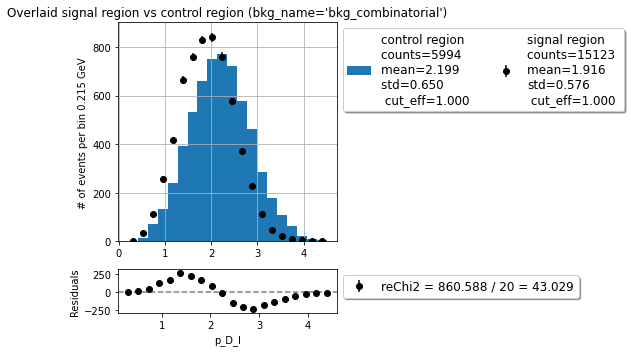

In [10]:
b2 = np.linspace(0.2,4.5,21)
mpl.plot_mc_sig_control(variable='p_D_l',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

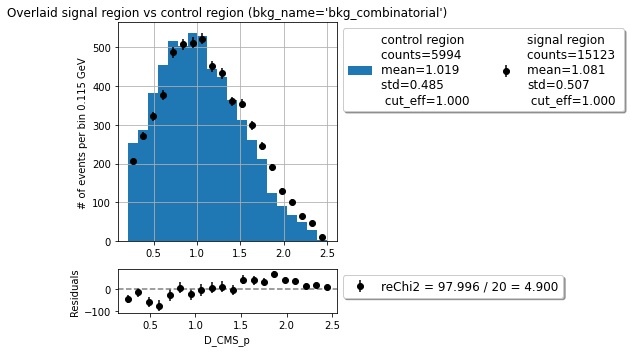

In [11]:
b2 = np.linspace(0.2,2.5,21)
mpl.plot_mc_sig_control(variable='D_CMS_p',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])

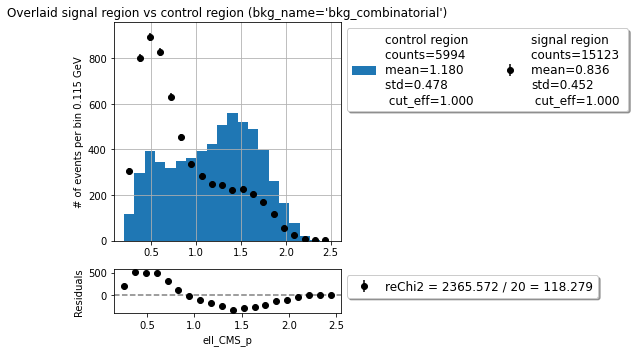

In [12]:
b2 = np.linspace(0.2,2.5,21)
mpl.plot_mc_sig_control(variable='ell_CMS_p',bins=b2,
                        bkg_name='bkg_combinatorial',cut=None,
                        samples_sig=samples_sig,
                        weights=weights,correction=False,mask=[])